# U-Net 산업단지 세그멘테이션


In [1]:
!pip -q install -U tifffile imagecodecs pillow
import tifffile, imagecodecs, PIL

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# === 여기를 본인 경로에 맞게 확인/수정 ===
DATA_ROOT = Path("/content/drive/MyDrive/mission3_data")

TR_IMG_DIR   = DATA_ROOT/"U-Net_Dataset/train/images"
TR_LABEL_DIR = DATA_ROOT/"U-Net_Dataset/train/labels"
VAL_IMG_DIR  = DATA_ROOT/"U-Net_Dataset/valid/images"
VAL_LABEL_DIR= DATA_ROOT/"U-Net_Dataset/valid/labels"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path
def list_pairs(img_dir, lbl_dir):
    imgs = sorted([p for p in Path(img_dir).glob("*.tif")])
    lbls = []
    for p in imgs:
        q = Path(lbl_dir)/(p.stem + ".tif")
        if not q.exists():
            raise FileNotFoundError(f"라벨 없음: {q.name}")
        lbls.append(q)
    return imgs, lbls

tr_imgs, tr_lbls = list_pairs(TR_IMG_DIR, TR_LABEL_DIR)
va_imgs, va_lbls = list_pairs(VAL_IMG_DIR, VAL_LABEL_DIR)
print(len(tr_imgs), len(va_imgs))


8000 1000


# 로더 설정: 4채널 유지 + 라벨 {10,90}→{0,1}

In [4]:
import numpy as np, tensorflow as tf, tifffile as tiff
tf.random.set_seed(42)

IMG_SIZE    = (512, 512)
NUM_CLASSES = 1   # sigmoid(1채널)
BATCH_SIZE  = 4
AUTOTUNE    = tf.data.AUTOTUNE
CLIP_MAX    = 10000.0

def read_tif_multiband_float(path_str):
    arr = tiff.imread(path_str.numpy().decode()).astype(np.float32)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], -1)
    arr = np.clip(arr, 0, CLIP_MAX) / CLIP_MAX
    return arr

def read_tif_mask_to_01(path_str):
    """TIFF 라벨을 {0,1} 이진 마스크로 변환: 10->1, 90->0 등"""
    path = path_str.numpy().decode()
    m = tiff.imread(path)
    if m.ndim == 3:
        m = m[..., 0]
    vals = np.unique(m)
    vset = set(vals.tolist())
    if vset == {10, 90}:
        m = (m == 10).astype(np.int32)
    elif vset == {0, 255}:
        m = (m > 0).astype(np.int32)
    elif vset.issubset({0, 1}):
        m = m.astype(np.int32)
    else:
        m = (m == vals.max()).astype(np.int32)
    return m

def load_pair(img_path, lbl_path):
    img = tf.py_function(read_tif_multiband_float, [img_path], tf.float32)
    msk = tf.py_function(read_tif_mask_to_01,      [lbl_path], tf.int32)
    img.set_shape([None, None, None])   # 채널 가변(여기선 4)
    msk.set_shape([None, None])         # (H,W)

    # 리사이즈: 라벨은 항상 nearest
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    msk = tf.image.resize(msk[..., None], IMG_SIZE, method="nearest")  # (H,W,1)
    # ★ one_hot 제거, float32 0/1로
    msk = tf.cast(tf.cast(msk, tf.float32) > 0.5, tf.float32) # (H,W,1) in {0,1}
    return img, msk

def augment(img, m):
    if tf.random.uniform([]) < 0.5:
        img = tf.image.flip_left_right(img); m = tf.image.flip_left_right(m)
    if tf.random.uniform([]) < 0.5:
        img = tf.image.flip_up_down(img);   m = tf.image.flip_up_down(m)
    if tf.random.uniform([]) < 0.2:
        img = tf.image.random_brightness(img, 0.05)
    if tf.random.uniform([]) < 0.2:
        img = tf.image.random_contrast(img, 0.95, 1.05)
    return img, m

def make_ds(imgs, lbls, train=True):
    ds = tf.data.Dataset.from_tensor_slices(([str(p) for p in imgs], [str(p) for p in lbls]))
    ds = ds.map(load_pair, num_parallel_calls=AUTOTUNE)            # (x, y) with y:(H,W,1)
    if train:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE).shuffle(1024, True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

def ensure_binary_mask(y):
    y = tf.cast(y, tf.float32)
    if y.shape.rank == 2:
        y = y[..., tf.newaxis]
    if y.shape.rank == 3 and y.shape[-1] == 2:
        y = y[..., 1:2]
    y = tf.where(y > 1.0, y / 255.0, y)
    y = tf.clip_by_value(y, 0.0, 1.0)
    y = tf.round(y)
    return y

train_ds = make_ds(tr_imgs, tr_lbls, True)
valid_ds = make_ds(va_imgs, va_lbls, False)


# U-Net 구성: 데이터 채널(4채널)에 자동 맞춤

In [5]:
from tensorflow.keras import layers, models

def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    return x
def enc(x, f): c=conv_block(x,f); p=layers.MaxPool2D(2)(c); return c,p
def dec(x, skip, f):
    x = layers.Conv2DTranspose(f, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    return conv_block(x, f)

# 배치에서 채널 수를 읽어 input_shape 자동 설정
example_x, _ = next(iter(train_ds))
H, W, C = example_x.shape[1], example_x.shape[2], example_x.shape[3]

inp = layers.Input((H, W, C))
s1,p1 = enc(inp,64);  s2,p2 = enc(p1,128); s3,p3 = enc(p2,256); s4,p4 = enc(p3,512)
b     = conv_block(p4,1024)
d1    = dec(b,s4,512); d2 = dec(d1,s3,256); d3 = dec(d2,s2,128); d4 = dec(d3,s1,64)
out = layers.Conv2D(1, 1, activation="sigmoid")(d4)
model = models.Model(inp, out)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │      2,368 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,873 (118.47 MB)

 Trainable params: 31,044,097 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

# 손실 함수(loss)와 메트릭(metric) 설정

In [6]:
@tf.function
def _binarize(x):
    return tf.where(x >= 0.5, 1.0, 0.0)

@tf.function
def binary_iou(y_true, y_pred, eps=tf.constant(1e-7, tf.float32)):
    y_true_b, y_pred_b = _binarize(y_true), _binarize(y_pred)
    inter = tf.reduce_sum(y_true_b * y_pred_b)
    union = tf.reduce_sum(
        tf.cast(tf.logical_or(tf.cast(y_true_b, tf.bool), tf.cast(y_pred_b, tf.bool)), tf.float32)
    )
    return (inter + eps) / (union + eps)

@tf.function
def binary_dice(y_true, y_pred, eps=tf.constant(1e-7, tf.float32)):
    y_true_b, y_pred_b = _binarize(y_true), _binarize(y_pred)
    inter = tf.reduce_sum(y_true_b * y_pred_b)
    return (2.0 * inter + eps) / (tf.reduce_sum(y_true_b) + tf.reduce_sum(y_pred_b) + eps)

@tf.function
def binary_accuracy(y_true, y_pred):
    y_true_b, y_pred_b = _binarize(y_true), _binarize(y_pred)
    return tf.reduce_mean(tf.cast(tf.equal(y_true_b, y_pred_b), tf.float32))

# MIOU

In [7]:
import tensorflow as tf
from pathlib import Path

binary_iou = tf.keras.metrics.BinaryIoU(threshold=0.5, name="mIoU")

class MeanIoUFromCM(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="mIoU", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes

        try:
            self.cm = self.add_weight(
                name="cm",
                shape=(num_classes, num_classes),
                initializer=tf.keras.initializers.Zeros(),
                dtype=tf.float32,
            )
        except TypeError:
            # 일부 TF/Keras 버전 호환용
            self.cm = tf.Variable(
                tf.zeros((num_classes, num_classes), dtype=tf.float32),
                trainable=False,
                name="cm",
            )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.argmax(y_true, axis=-1)
        y_pred = tf.argmax(y_pred, axis=-1)
        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.reshape(y_pred, [-1])
        cm = tf.math.confusion_matrix(
            y_true, y_pred, num_classes=self.num_classes, dtype=tf.float32
        )
        self.cm.assign_add(cm)

    def result(self):
        cm = self.cm
        tp = tf.linalg.diag_part(cm)
        sum_row = tf.reduce_sum(cm, axis=0)  # predicted
        sum_col = tf.reduce_sum(cm, axis=1)  # true
        denom = sum_row + sum_col - tp
        iou = tf.math.divide_no_nan(tp, denom)
        return tf.reduce_mean(iou)

    def reset_states(self):
        self.cm.assign(tf.zeros_like(self.cm))

    # 일부 버전 호환
    def reset_state(self):
        self.reset_states()

# === 컴파일 & 콜백 ===
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[binary_iou, binary_dice, binary_accuracy]
)

CKPT = Path("/content/drive/MyDrive/mission3_data/checkpoints/unet_sigmoid_best.keras"); CKPT.parent.mkdir(parents=True, exist_ok=True)
cbs = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mIoU", mode="max", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_mIoU", mode="max", patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(CKPT, monitor="val_mIoU", mode="max", save_best_only=True, verbose=1),
]


# 학습 → 평가

In [8]:
history = model.fit(train_ds, validation_data=valid_ds, epochs=30, callbacks=cbs)

res = model.evaluate(valid_ds, return_dict=True)
print(res)  # 'mIoU' 확인



Epoch 1/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - binary_accuracy: 0.9082 - binary_dice: 0.6944 - loss: 0.2237 - mIoU: 0.7186
Epoch 1: val_mIoU improved from -inf to 0.77871, saving model to /content/drive/MyDrive/mission3_data/checkpoints/unet_sigmoid_best.keras
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 650s 292ms/step - binary_accuracy: 0.9083 - binary_dice: 0.6944 - loss: 0.2237 - mIoU: 0.7186 - val_binary_accuracy: 0.9253 - val_binary_dice: 0.7753 - val_loss: 0.1743 - val_mIoU: 0.7787 - learning_rate: 3.0000e-04
Epoch 2/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - binary_accuracy: 0.9380 - binary_dice: 0.8051 - loss: 0.1476 - mIoU: 0.8031
Epoch 2: val_mIoU improved from 0.77871 to 0.80486, saving model to /content/drive/MyDrive/mission3_data/checkpoints/unet_sigmoid_best.keras
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 255s 122ms/step - binary_accuracy: 0.9380 - binary_dice: 0.8051 - loss: 0.1476 - mIoU: 0.8031 - val_binary_accuracy: 0.9330 - val_binary_dice: 0.8069 - val_loss: 0.1626 - val_

# 시각화

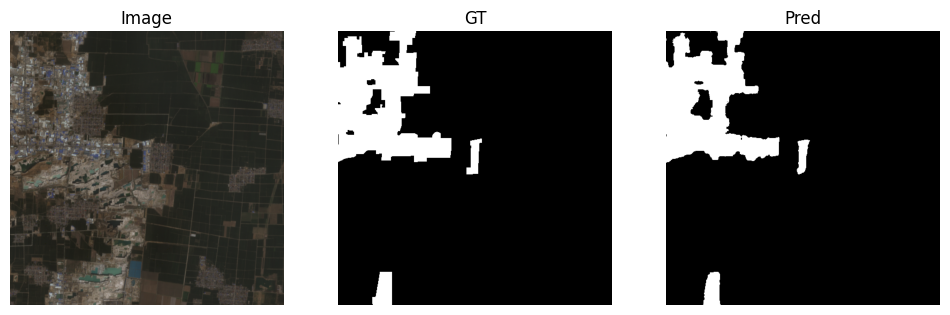

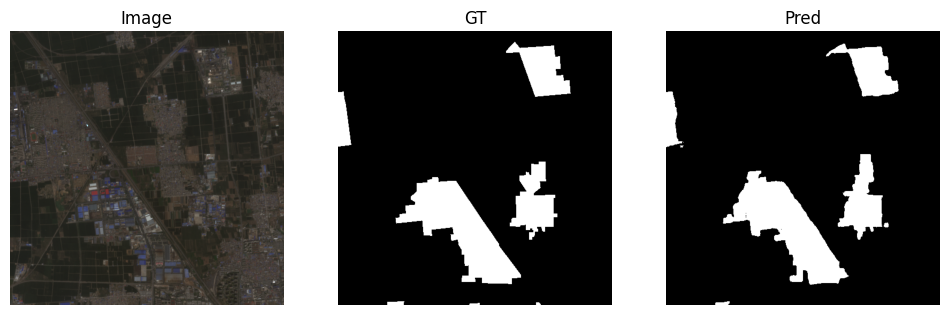

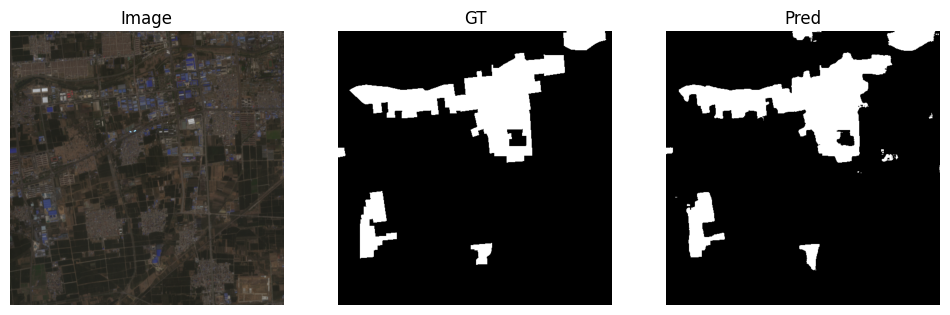

Best saved to: /content/drive/MyDrive/mission3_data/checkpoints/unet_sigmoid_best.keras


In [9]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

def show_samples(ds, n=3, thresh=0.5):
    for imgs, masks in ds.take(1):
        preds = model.predict(imgs, verbose=0)

        # sigmoid 출력 -> threshold 로 이진화
        gt = masks.numpy().squeeze()         # (B,H,W,1) -> (B,H,W)
        pr = (preds > thresh).astype(np.float32).squeeze()

        for i in range(min(n, imgs.shape[0])):
            img = imgs[i].numpy()

            # 4채널이면 앞 3밴드만 시각화
            if img.ndim == 3 and img.shape[-1] > 3:
                img_vis = img[..., :3]
            else:
                img_vis = img

            # 값 범위 보정
            if img_vis.max() > 1.0:
                img_vis = img_vis / img_vis.max()

            fig, ax = plt.subplots(1, 3, figsize=(12, 4))
            ax[0].imshow(img_vis)
            ax[0].set_title("Image"); ax[0].axis("off")

            ax[1].imshow(gt[i], cmap="gray", vmin=0, vmax=1)
            ax[1].set_title("GT"); ax[1].axis("off")

            ax[2].imshow(pr[i], cmap="gray", vmin=0, vmax=1)
            ax[2].set_title("Pred"); ax[2].axis("off")

            plt.show()

show_samples(valid_ds, n=3)
print("Best saved to:", CKPT)